# BERTimbau — classificação **direta** de emoções de Ekman (GoEmotions PT-BR)

## Instalação (se necessário)

In [1]:
# !pip install transformers[torch] torch torchmetrics pandas numpy scikit-learn pyarrow sentencepiece protobuf scipy matplotlib

## Ambiente (Colab/Drive opcional)

In [2]:
USE_COLAB = False
USE_DRIVE = False

if USE_COLAB and USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")

## Imports e configurações globais

In [3]:
import warnings
warnings.filterwarnings("ignore")

import io, re, gzip, lzma, json, time, math, zipfile
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Optimizer

from transformers import AutoTokenizer, AutoModel, DataCollatorWithPadding

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, hamming_loss, average_precision_score,
)
from scipy.stats import wilcoxon

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

RANDOM_STATE = 42

if USE_COLAB and USE_DRIVE:
    ROOT = Path("/content/drive/MyDrive/Fuzzy_BERT")
else:
    ROOT = Path("..")

DATA_DIR  = ROOT / "data/treated"
OUT_BASE  = ROOT / "data/out"
CKPT_BASE = ROOT / "data/checkpoints"

N_OUTER_FOLDS = 5
TEXT_COL   = "CLEAN_TEXT"
MAX_LEN    = 128
BATCH_SIZE = 32
WARMUP_RATIO  = 0.1
LEARNING_RATE = 2e-5
VAL_FRACTION  = 0.10
NUM_EPOCHS    = 4

THRESH_GRID     = np.linspace(0.05, 0.95, 19)
FIXED_THRESHOLD = 0.5

COMPRESSION       = "xz"
SAVE_BEST_FP16    = True
PRUNE_RESUME_CKPT = True

MODEL_NAME = "neuralmind/bert-base-portuguese-cased"   # BERTimbau
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 28 colunas finas de origem (para construir os rótulos de Ekman)
EMOTION_COLS_28 = [
    'admiration','amusement','anger','annoyance','approval','caring','confusion','curiosity',
    'desire','disappointment','disapproval','disgust','embarrassment','excitement','fear',
    'gratitude','grief','joy','love','nervousness','optimism','pride','realization','relief',
    'remorse','sadness','surprise','neutral'
]

# ---- rótulos-alvo: 6 grupos de Ekman + neutral (ordem fixa) ----
EKMAN7 = ["anger", "disgust", "fear", "joy", "sadness", "surprise", "neutral"]
N_LABELS = len(EKMAN7)

# mapeamento fino -> Ekman (oficial GoEmotions); neutral mapeia para si mesmo
EKMAN_FROM_FINE = {
    "anger":    ["anger", "annoyance", "disapproval"],
    "disgust":  ["disgust"],
    "fear":     ["fear", "nervousness"],
    "joy":      ["admiration", "amusement", "approval", "caring", "desire", "excitement",
                 "gratitude", "joy", "love", "optimism", "pride", "relief"],
    "sadness":  ["sadness", "disappointment", "embarrassment", "grief", "remorse"],
    "surprise": ["surprise", "realization", "confusion", "curiosity"],
}
# Ekman -> sentimento (aninhamento exato)
SENT_FROM_EKMAN = {
    "positive":  ["joy"],
    "negative":  ["anger", "disgust", "fear", "sadness"],
    "ambiguous": ["surprise"],
    "neutral":   ["neutral"],
}
SENT4 = list(SENT_FROM_EKMAN.keys())

# checagem de cobertura: as 27 emoções finas aparecem exatamente uma vez no mapa de Ekman
_fine_no_neutral = [c for c in EMOTION_COLS_28 if c != "neutral"]
assert sorted(sum(EKMAN_FROM_FINE.values(), [])) == sorted(_fine_no_neutral)

OUT_DIR  = OUT_BASE  / "bert_ekman"
CKPT_DIR = CKPT_BASE / "bert_ekman"
(OUT_DIR / "cache").mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

torch.manual_seed(RANDOM_STATE); np.random.seed(RANDOM_STATE)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

print(f"Device : {DEVICE}")
print(f"Modelo : {MODEL_NAME}")
print(f"Alvo   : {N_LABELS} rótulos de Ekman -> {EKMAN7}")
print(f"Sent.  : {SENT4} (derivado de Ekman, mapeamento exato)")

Device : cuda
Modelo : neuralmind/bert-base-portuguese-cased
Alvo   : 7 rótulos de Ekman -> ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'neutral']
Sent.  : ['positive', 'negative', 'ambiguous', 'neutral'] (derivado de Ekman, mapeamento exato)


## Construção dos rótulos de Ekman (7) a partir das 28 colunas finas

In [4]:
def build_ekman_df(df):
    """df (28 colunas finas + CLEAN_TEXT) -> df com 7 colunas de Ekman + CLEAN_TEXT (multi-label)."""
    out = pd.DataFrame(index=df.index)
    for g, members in EKMAN_FROM_FINE.items():
        out[g] = (df[members].sum(axis=1) > 0).astype(int)
    out["neutral"] = df["neutral"].astype(int)
    out = out[EKMAN7]                      # garante a ordem
    out[TEXT_COL] = df[TEXT_COL].values
    return out.reset_index(drop=True)

def load_fold(fold_id):
    return pd.read_parquet(DATA_DIR / f"fold_{fold_id}" / "data.parquet")

folds_ek = {}
for k in range(1, N_OUTER_FOLDS + 1):
    raw = load_fold(k)
    missing = [c for c in EMOTION_COLS_28 if c not in raw.columns]
    assert not missing, f"Fold {k} sem colunas finas: {missing}"
    folds_ek[k] = build_ekman_df(raw)

Y_folds = {k: folds_ek[k][EKMAN7].values.astype(int) for k in folds_ek}
base = pd.Series(np.vstack(list(Y_folds.values())).mean(axis=0), index=EKMAN7)
cardin = np.vstack(list(Y_folds.values())).sum(axis=1)

print("Rótulos de Ekman construídos.\n")
print("Frequência (base rate) por rótulo de Ekman:")
for g in EKMAN7:
    print(f"  {g:9s}: {base[g]:.4f}")
print(f"\nMédia de rótulos por texto: {cardin.mean():.3f}  |  "
      f"multi-label (>1 rótulo): {100*(cardin>1).mean():.1f}%  |  "
      f"sem rótulo: {100*(cardin==0).mean():.1f}%")

Rótulos de Ekman construídos.

Frequência (base rate) por rótulo de Ekman:
  anger    : 0.1295
  disgust  : 0.0187
  fear     : 0.0171
  joy      : 0.4007
  sadness  : 0.0743
  surprise : 0.1229
  neutral  : 0.3273

Média de rótulos por texto: 1.090  |  multi-label (>1 rótulo): 8.8%  |  sem rótulo: 0.0%


## Dataset e DataLoader (7 rótulos de Ekman)

In [5]:
class EmotionDataset(Dataset):
    def __init__(self, df, tokenizer, label_cols=EKMAN7, max_len=MAX_LEN):
        self.texts = df[TEXT_COL].fillna("").astype(str).tolist()
        self.labels = df[label_cols].values.astype(np.float32)
        self.tokenizer = tokenizer; self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(self.texts[idx], max_length=self.max_len, truncation=True)
        enc["labels"] = self.labels[idx].tolist()
        return enc

def make_loaders(df_train, df_eval, tokenizer, shuffle_train=True):
    collator = DataCollatorWithPadding(tokenizer, padding="longest", return_tensors="pt")
    lt = DataLoader(EmotionDataset(df_train, tokenizer), batch_size=BATCH_SIZE,
                    shuffle=shuffle_train, num_workers=0, pin_memory=True, collate_fn=collator)
    le = DataLoader(EmotionDataset(df_eval, tokenizer), batch_size=BATCH_SIZE,
                    shuffle=False, num_workers=0, pin_memory=True, collate_fn=collator)
    return lt, le

def split_train_val(df_trainfull, val_fraction=VAL_FRACTION, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed); n = len(df_trainfull); perm = rng.permutation(n)
    nv = max(1, int(round(n * val_fraction)))
    return (df_trainfull.iloc[perm[nv:]].reset_index(drop=True),
            df_trainfull.iloc[perm[:nv]].reset_index(drop=True))

print("Dataset e loaders prontos (7 rótulos).")

Dataset e loaders prontos (7 rótulos).


## Modelo — BERTimbau + cabeça multi-label (7 saídas)

In [6]:
class TransformerForEmotions(nn.Module):
    def __init__(self, model_name, n_labels=N_LABELS, dropout=0.1):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name, torch_dtype=torch.float32)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, n_labels)
    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(self.dropout(out.last_hidden_state[:, 0, :]))

def build_model():
    return TransformerForEmotions(MODEL_NAME).to(DEVICE)

print("Modelo definido (7 saídas de Ekman).")

Modelo definido (7 saídas de Ekman).


## Class-Balanced Loss (idêntica ao baseline)

In [7]:
class CrossBalancedLoss(nn.Module):
    def __init__(self, samples_per_class, beta=0.9999):
        super().__init__()
        eff = 1.0 - np.power(beta, samples_per_class)
        w = (1.0 - beta) / np.where(eff == 0, 1e-8, eff)
        w = w / w.sum() * len(samples_per_class)
        self.register_buffer("weights", torch.tensor(w, dtype=torch.float32))
    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        return (bce * self.weights.unsqueeze(0)).mean()

def compute_samples_per_class(df, label_cols=EKMAN7):
    counts = np.array([int(df[c].sum()) for c in label_cols], dtype=np.float64)
    return np.maximum(counts, 1)

print("CrossBalancedLoss definida.")

CrossBalancedLoss definida.


## Otimizador e scheduler (idênticos ao baseline)

In [8]:
class AdamWeightDecayOptimizer(Optimizer):
    def __init__(self, params, lr=2e-5, weight_decay_rate=0.01,
                 beta_1=0.9, beta_2=0.999, epsilon=1e-6, exclude_from_weight_decay=None):
        if exclude_from_weight_decay is None:
            exclude_from_weight_decay = ["LayerNorm", "layer_norm", "bias"]
        defaults = dict(lr=lr, weight_decay_rate=weight_decay_rate, beta_1=beta_1,
                        beta_2=beta_2, epsilon=epsilon,
                        exclude_from_weight_decay=exclude_from_weight_decay)
        super().__init__(params, defaults)
    def _use_wd(self, name, exclude):
        return not any(re.search(p, name) for p in exclude)
    @torch.no_grad()
    def step(self, closure=None):
        loss = closure() if closure is not None else None
        for g in self.param_groups:
            b1, b2, eps = g["beta_1"], g["beta_2"], g["epsilon"]
            wd, lr = g["weight_decay_rate"], g["lr"]
            exclude = g["exclude_from_weight_decay"]; names = g.get("_param_names", {})
            for p in g["params"]:
                if p.grad is None: continue
                grad = p.grad.data; st = self.state[p]
                if len(st) == 0:
                    st["m"] = torch.zeros_like(p.data); st["v"] = torch.zeros_like(p.data); st["step"]=0
                m, v = st["m"], st["v"]; st["step"] += 1
                nm = b1*m + (1.0-b1)*grad
                nv = b2*v + (1.0-b2)*grad.pow(2)
                upd = nm / (nv.sqrt() + eps)
                if wd > 0 and self._use_wd(names.get(id(p), ""), exclude):
                    upd = upd + wd * p.data
                p.data.add_(upd, alpha=-lr); st["m"].copy_(nm); st["v"].copy_(nv)
        return loss

def _param_groups(model, exclude=("LayerNorm","layer_norm","bias")):
    decay, no_decay, names = [], [], {}
    for n, p in model.named_parameters():
        if not p.requires_grad: continue
        names[id(p)] = n
        (no_decay if any(re.search(e, n) for e in exclude) else decay).append(p)
    return decay, no_decay, names

def build_optimizer(model, lr=LEARNING_RATE):
    decay, no_decay, names = _param_groups(model)
    groups = [{"params": decay, "weight_decay_rate": 0.01},
              {"params": no_decay, "weight_decay_rate": 0.0}]
    opt = AdamWeightDecayOptimizer(groups, lr=lr, weight_decay_rate=0.01,
                                   beta_1=0.9, beta_2=0.999, epsilon=1e-6)
    for gp in opt.param_groups:
        gp["_param_names"] = names
    return opt

def build_scheduler(optimizer, num_steps, warmup_ratio=WARMUP_RATIO):
    from torch.optim.lr_scheduler import LambdaLR
    nw = int(num_steps * warmup_ratio)
    def lr_lambda(step):
        if step < nw: return float(step)/float(max(1, nw))
        prog = float(step-nw)/float(max(1, num_steps-nw))
        return max(0.0, 1.0-prog)
    return LambdaLR(optimizer, lr_lambda)

print("Otimizador e scheduler prontos.")

Otimizador e scheduler prontos.


## Checkpoints compactados + treino/avaliação + métricas (idênticos ao baseline)

In [9]:
def _compress(raw):
    if COMPRESSION=="gzip": return gzip.compress(raw, 6)
    if COMPRESSION=="xz":   return lzma.compress(raw, preset=6)
    if COMPRESSION=="zip":
        buf=io.BytesIO()
        with zipfile.ZipFile(buf,"w",zipfile.ZIP_DEFLATED,compresslevel=6) as z: z.writestr("ckpt.pt", raw)
        return buf.getvalue()
    raise ValueError(COMPRESSION)

def _decompress(data):
    if data[:2]==b"\x1f\x8b": return gzip.decompress(data)
    if data[:6]==b"\xfd7zXZ\x00": return lzma.decompress(data)
    if data[:2]==b"PK":
        with zipfile.ZipFile(io.BytesIO(data)) as z: return z.read(z.namelist()[0])
    return data

def torch_save_compressed(payload, path):
    buf=io.BytesIO(); torch.save(payload, buf); Path(path).write_bytes(_compress(buf.getvalue()))

def torch_load_compressed(path, map_location=None, weights_only=False):
    import numpy.dtypes
    torch.serialization.add_safe_globals([numpy.dtypes.Float64DType])
    raw=_decompress(Path(path).read_bytes())
    return torch.load(io.BytesIO(raw), map_location=map_location, weights_only=weights_only)

def save_resume_ckpt(model, opt, sch, epoch, fold, ckpt_dir):
    torch_save_compressed({"epoch":epoch,"fold":fold,"model_state_dict":model.state_dict(),
        "optimizer_state_dict":opt.state_dict(),"scheduler_state_dict":sch.state_dict()},
        Path(ckpt_dir)/f"fold_{fold}_last.ptz")

def save_best_ckpt(model, epoch, fold, val_metrics, ckpt_dir):
    sd=model.state_dict()
    if SAVE_BEST_FP16: sd={k:(v.half() if v.is_floating_point() else v) for k,v in sd.items()}
    torch_save_compressed({"epoch":epoch,"fold":fold,"val_metrics":val_metrics,
        "model_state_dict":sd,"fp16":SAVE_BEST_FP16}, Path(ckpt_dir)/f"fold_{fold}_best.ptz")

def load_model_weights(model, ckpt_path):
    ck=torch_load_compressed(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ck["model_state_dict"]); return ck

def train_one_epoch(model, loader, opt, sch, criterion, device):
    model.train(); total=0.0
    for batch in loader:
        ids=batch["input_ids"].to(device); am=batch["attention_mask"].to(device)
        y=batch["labels"].to(device)
        opt.zero_grad()
        logits=model(input_ids=ids, attention_mask=am)
        loss=criterion(logits, y); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sch.step(); total+=loss.item()
    return total/max(len(loader),1)

@torch.no_grad()
def infer_proba(model, loader, device):
    model.eval(); L=[]; Y=[]
    for batch in loader:
        ids=batch["input_ids"].to(device); am=batch["attention_mask"].to(device)
        L.append(model(input_ids=ids, attention_mask=am).detach().cpu())
        Y.append(batch["labels"])
    L=torch.cat(L); Y=torch.cat(Y)
    return torch.sigmoid(L).numpy(), Y.numpy().astype(int)

def compute_metrics(Y_true, Y_pred, Y_proba, label_names):
    m = {
        "accuracy":        accuracy_score(Y_true, Y_pred),
        "hamming_loss":    hamming_loss(Y_true, Y_pred),
        "f1_macro":        f1_score(Y_true, Y_pred, average="macro",    zero_division=0),
        "f1_micro":        f1_score(Y_true, Y_pred, average="micro",    zero_division=0),
        "f1_weighted":     f1_score(Y_true, Y_pred, average="weighted", zero_division=0),
        "precision_macro": precision_score(Y_true, Y_pred, average="macro", zero_division=0),
        "recall_macro":    recall_score(Y_true, Y_pred, average="macro",    zero_division=0),
    }
    valid=[j for j in range(Y_true.shape[1]) if Y_true[:, j].sum()>0]
    if valid:
        m["roc_auc_macro"]=roc_auc_score(Y_true[:,valid], Y_proba[:,valid], average="macro")
        m["avg_precision_macro"]=average_precision_score(Y_true[:,valid], Y_proba[:,valid], average="macro")
    else:
        m["roc_auc_macro"]=m["avg_precision_macro"]=float("nan")
    m["f1_per_label"]=dict(zip(label_names, f1_score(Y_true, Y_pred, average=None, zero_division=0)))
    return m

print("Checkpoints + treino/avaliação + métricas prontos.")

Checkpoints + treino/avaliação + métricas prontos.


## Treino + OOF (CV aninhada, com *resume*)

Para cada *fold* externo `k`: treina nos demais (validação interna para escolher a época) e gera as
probabilidades OOF no *fold* `k`. Tudo já nos 7 rótulos de Ekman.

In [10]:
def oof_path(k):     return OUT_DIR / "cache" / f"P_ekman_fold{k}.npy"
def history_path(k): return CKPT_DIR / f"fold_{k}_history.json"

def train_fold(k, tokenizer):
    op = oof_path(k)
    if op.exists():
        print(f"    [cache] OOF do fold {k} já existe."); return np.load(op)

    df_test = folds_ek[k]
    df_full = pd.concat([folds_ek[j] for j in range(1, N_OUTER_FOLDS+1) if j != k], ignore_index=True)
    df_tr, df_val = split_train_val(df_full)

    loader_train, _ = make_loaders(df_tr, df_val, tokenizer, shuffle_train=True)
    _, loader_val   = make_loaders(df_tr, df_val, tokenizer, shuffle_train=False)
    _, loader_test  = make_loaders(df_tr, df_test, tokenizer, shuffle_train=False)

    criterion = CrossBalancedLoss(compute_samples_per_class(df_tr), beta=0.9999).to(DEVICE)
    model = build_model()
    num_steps = len(loader_train) * NUM_EPOCHS
    opt = build_optimizer(model); sch = build_scheduler(opt, num_steps)

    history = json.loads(history_path(k).read_text()) if history_path(k).exists() else []
    best_val = max([h["val_f1_macro"] for h in history], default=-1.0)

    start_epoch = 1
    last_ckpt = CKPT_DIR / f"fold_{k}_last.ptz"
    if last_ckpt.exists():
        ck = torch_load_compressed(last_ckpt, map_location=DEVICE)
        model.load_state_dict(ck["model_state_dict"]); opt.load_state_dict(ck["optimizer_state_dict"])
        sch.load_state_dict(ck["scheduler_state_dict"]); start_epoch = ck["epoch"] + 1
        print(f"    retomando fold {k} da época {start_epoch}")

    for epoch in range(start_epoch, NUM_EPOCHS + 1):
        t0 = time.time()
        tr_loss = train_one_epoch(model, loader_train, opt, sch, criterion, DEVICE)
        vp, vt = infer_proba(model, loader_val, DEVICE)
        vf1 = f1_score(vt, (vp >= FIXED_THRESHOLD).astype(int), average="macro", zero_division=0)
        history.append({"epoch":epoch, "val_f1_macro":float(vf1), "train_loss":float(tr_loss)})
        history_path(k).write_text(json.dumps(history, ensure_ascii=False, indent=1))
        save_resume_ckpt(model, opt, sch, epoch, k, CKPT_DIR)
        improved = vf1 > best_val
        if improved:
            best_val = vf1; save_best_ckpt(model, epoch, k, {"val_f1_macro":vf1}, CKPT_DIR)
        print(f"    época {epoch}/{NUM_EPOCHS} | train_loss={tr_loss:.4f} | "
              f"val_f1={vf1:.4f}{' *' if improved else ''} | {time.time()-t0:.0f}s")

    load_model_weights(model, CKPT_DIR / f"fold_{k}_best.ptz")
    P_test, _ = infer_proba(model, loader_test, DEVICE)
    np.save(op, P_test)
    if PRUNE_RESUME_CKPT and last_ckpt.exists(): last_ckpt.unlink()
    del model, opt, sch, criterion
    if DEVICE.type == "cuda": torch.cuda.empty_cache()
    return P_test

print(f"\n{'='*66}\n  TREINO — BERTimbau · Ekman (7 rótulos, multi-label)\n{'='*66}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
PROBA = {}
for k in range(1, N_OUTER_FOLDS + 1):
    print(f"  Fold {k}/{N_OUTER_FOLDS}  (teste: {len(folds_ek[k])} amostras)")
    PROBA[k] = train_fold(k, tokenizer)
print("\n✓ OOF pronto para os 5 folds.")


  TREINO — BERTimbau · Ekman (7 rótulos, multi-label)


  Fold 1/5  (teste: 10831 amostras)


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 45660.09it/s]
[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    época 1/4 | train_loss=0.1425 | val_f1=0.5022 * | 634s
    época 2/4 | train_loss=0.1021 | val_f1=0.5355 * | 633s
    época 3/4 | train_loss=0.0858 | val_f1=0.5509 * | 625s
    época 4/4 | train_loss=0.0739 | val_f1=0.5445 | 557s
  Fold 2/5  (teste: 10810 amostras)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 27465.17it/s]
[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

    época 1/4 | train_loss=0.1488 | val_f1=0.5509 * | 617s
    época 2/4 | train_loss=0.1028 | val_f1=0.5720 * | 630s
    época 3/4 | train_loss=0.0870 | val_f1=0.5754 * | 626s
    época 4/4 | train_loss=0.0745 | val_f1=0.5866 * | 633s
  Fold 4/5  (teste: 10909 amostras)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 25283.73it/s]
[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    época 1/4 | train_loss=0.1453 | val_f1=0.5316 * | 661s
    época 2/4 | train_loss=0.1031 | val_f1=0.5308 | 577s
    época 3/4 | train_loss=0.0873 | val_f1=0.5633 * | 620s
    época 4/4 | train_loss=0.0750 | val_f1=0.5560 | 546s
  Fold 5/5  (teste: 10848 amostras)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 18662.19it/s]
[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    época 1/4 | train_loss=0.1488 | val_f1=0.5276 * | 618s
    época 2/4 | train_loss=0.1027 | val_f1=0.5621 * | 622s
    época 3/4 | train_loss=0.0866 | val_f1=0.5581 | 548s
    época 4/4 | train_loss=0.0749 | val_f1=0.5678 * | 628s

✓ OOF pronto para os 5 folds.


## Calibração de limiar (@0.5 e @limiar) e métricas de Ekman

In [11]:
def calibrate_thresholds(P_cal, Y_cal, grid, n_labels=N_LABELS):
    thr = np.full(n_labels, FIXED_THRESHOLD)
    for j in range(n_labels):
        y = Y_cal[:, j]
        if y.sum() == 0: continue
        pred = P_cal[:, j][:, None] >= grid[None, :]
        yb = (y == 1)[:, None]
        tp = (pred & yb).sum(0); fp = (pred & ~yb).sum(0); fn = (~pred & yb).sum(0)
        f1 = 2*tp / np.maximum(2*tp + fp + fn, 1e-12)
        thr[j] = float(grid[int(np.argmax(f1))])
    return thr

def metrics_at(Y_true, P_score, thr_vec, label_cols=EKMAN7):
    Y_pred = (P_score >= thr_vec[None, :]).astype(int)
    return compute_metrics(Y_true, Y_pred, P_score, label_cols)

ekman_fixed, ekman_tuned = [], []
thresholds_store = {}
for k in range(1, N_OUTER_FOLDS + 1):
    train_ks = [j for j in range(1, N_OUTER_FOLDS+1) if j != k]
    P_cal = np.vstack([PROBA[j] for j in train_ks]); Y_cal = np.vstack([Y_folds[j] for j in train_ks])
    thr = calibrate_thresholds(P_cal, Y_cal, THRESH_GRID)
    thresholds_store[k] = thr
    m_fix = metrics_at(Y_folds[k], PROBA[k], np.full(N_LABELS, FIXED_THRESHOLD)); m_fix["outer_fold"]=k
    m_tun = metrics_at(Y_folds[k], PROBA[k], thr);                                m_tun["outer_fold"]=k
    ekman_fixed.append(m_fix); ekman_tuned.append(m_tun)

thr_mean = np.vstack([thresholds_store[k] for k in thresholds_store]).mean(axis=0)
print("Limiar calibrado médio por rótulo de Ekman:")
for g, t in zip(EKMAN7, thr_mean): print(f"  {g:9s}: {t:.3f}")
print(f"\nEkman F1-macro @0.5    : {np.mean([m['f1_macro'] for m in ekman_fixed]):.4f} "
      f"± {np.std([m['f1_macro'] for m in ekman_fixed]):.4f}")
print(f"Ekman F1-macro @limiar : {np.mean([m['f1_macro'] for m in ekman_tuned]):.4f} "
      f"± {np.std([m['f1_macro'] for m in ekman_tuned]):.4f}")

Limiar calibrado médio por rótulo de Ekman:
  anger    : 0.250
  disgust  : 0.300
  fear     : 0.350
  joy      : 0.410
  sadness  : 0.430
  surprise : 0.270
  neutral  : 0.240

Ekman F1-macro @0.5    : 0.5631 ± 0.0075
Ekman F1-macro @limiar : 0.5814 ± 0.0044


## Sentimento a partir de Ekman (mapeamento exato)

`joy → positive` · `{anger, disgust, fear, sadness} → negative` · `surprise → ambiguous` ·
`neutral → neutral`. O `Y` verdadeiro e o predito de sentimento são obtidos por OR das colunas de
Ekman correspondentes (mesmo limiar calibrado).

In [12]:
def ekman_to_sentiment(Y_ekman):
    idx = {g: i for i, g in enumerate(EKMAN7)}
    S = np.zeros((len(Y_ekman), len(SENT4)), dtype=int)
    for si, s in enumerate(SENT4):
        cols = [idx[g] for g in SENT_FROM_EKMAN[s]]
        S[:, si] = (Y_ekman[:, cols].sum(axis=1) > 0).astype(int)
    return S

sent_fixed, sent_tuned = [], []
for k in range(1, N_OUTER_FOLDS + 1):
    thr = thresholds_store[k]
    Yt_sent = ekman_to_sentiment(Y_folds[k])
    Yp_fix  = ekman_to_sentiment((PROBA[k] >= FIXED_THRESHOLD).astype(int))
    Yp_tun  = ekman_to_sentiment((PROBA[k] >= thr[None, :]).astype(int))
    f1f = f1_score(Yt_sent, Yp_fix, average=None, zero_division=0)
    f1t = f1_score(Yt_sent, Yp_tun, average=None, zero_division=0)
    sent_fixed.append({"macro": f1_score(Yt_sent, Yp_fix, average="macro", zero_division=0),
                       **dict(zip(SENT4, f1f)), "outer_fold": k})
    sent_tuned.append({"macro": f1_score(Yt_sent, Yp_tun, average="macro", zero_division=0),
                       **dict(zip(SENT4, f1t)), "outer_fold": k})

print(f"Sentimento F1-macro @0.5    : {np.mean([m['macro'] for m in sent_fixed]):.4f} "
      f"± {np.std([m['macro'] for m in sent_fixed]):.4f}")
print(f"Sentimento F1-macro @limiar : {np.mean([m['macro'] for m in sent_tuned]):.4f} "
      f"± {np.std([m['macro'] for m in sent_tuned]):.4f}")

Sentimento F1-macro @0.5    : 0.6298 ± 0.0058
Sentimento F1-macro @limiar : 0.6551 ± 0.0043


## Resultados — Ekman (7) e Sentimento (4)

In [13]:
def ms(vals): 
    v = np.array(vals, float); return f"{v.mean():.4f} ± {v.std():.4f}"

# tabela resumo
summary_rows = [
    {"Nível": "Ekman (7 rótulos)",
     "F1-macro @0.5": ms([m["f1_macro"] for m in ekman_fixed]),
     "F1-macro @limiar": ms([m["f1_macro"] for m in ekman_tuned]),
     "F1-micro @limiar": ms([m["f1_micro"] for m in ekman_tuned]),
     "ROC-AUC macro": ms([m["roc_auc_macro"] for m in ekman_tuned])},
    {"Nível": "Sentimento (4)",
     "F1-macro @0.5": ms([m["macro"] for m in sent_fixed]),
     "F1-macro @limiar": ms([m["macro"] for m in sent_tuned]),
     "F1-micro @limiar": "—", "ROC-AUC macro": "—"},
]
df_summary = pd.DataFrame(summary_rows).set_index("Nível")
print("===== BERTimbau · Ekman direto — resumo (média ± desvio, 5 folds) =====")
display(df_summary)

# F1 por rótulo de Ekman (@limiar)
f1_ek = pd.DataFrame([m["f1_per_label"] for m in ekman_tuned]).mean().reindex(EKMAN7)
print("\nF1 por rótulo de Ekman (@limiar, média entre folds):")
for g in EKMAN7: print(f"  {g:9s}: {f1_ek[g]:.4f}")

# F1 por classe de sentimento (@limiar)
print("\nF1 por classe de sentimento (@limiar, média entre folds):")
for s in SENT4:
    print(f"  {s:9s}: {np.mean([m[s] for m in sent_tuned]):.4f}")

===== BERTimbau · Ekman direto — resumo (média ± desvio, 5 folds) =====


,F1-macro @0.5,F1-macro @limiar,F1-micro @limiar,ROC-AUC macro
Nível,,,,
Ekman (7 rótulos),0.5631 ± 0.0075,0.5814 ± 0.0044,0.6633 ± 0.0016,0.8844 ± 0.0030
Sentimento (4),0.6298 ± 0.0058,0.6551 ± 0.0043,—,—



F1 por rótulo de Ekman (@limiar, média entre folds):
  anger    : 0.5220
  disgust  : 0.4148
  fear     : 0.5784
  joy      : 0.8018
  sadness  : 0.5888
  surprise : 0.5044
  neutral  : 0.6596

F1 por classe de sentimento (@limiar, média entre folds):
  positive : 0.8018
  negative : 0.6548
  ambiguous: 0.5044
  neutral  : 0.6596


## Gráficos

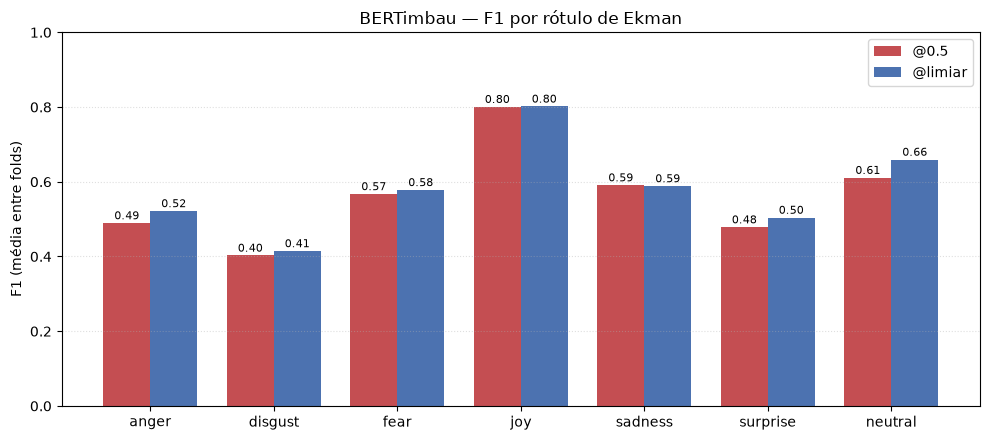

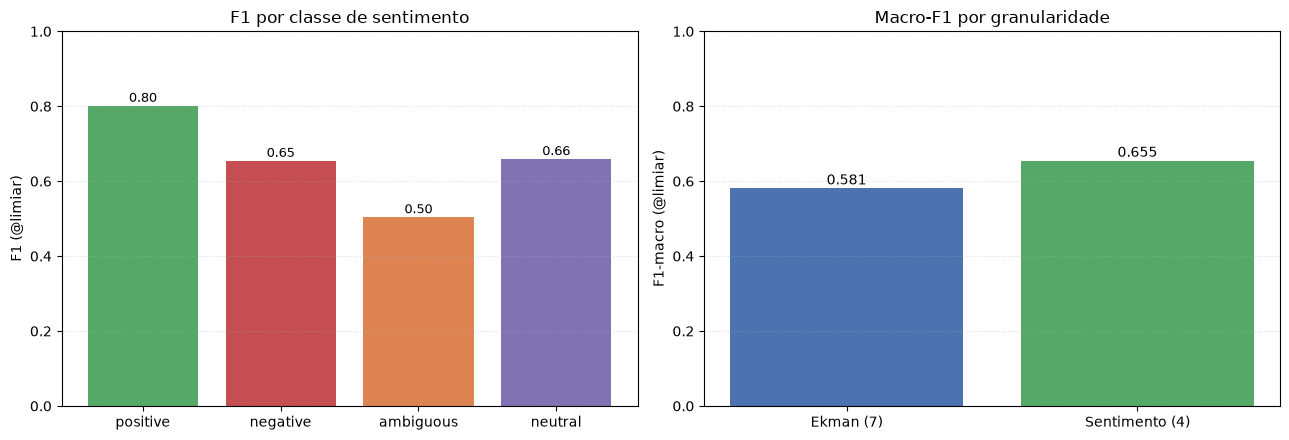

In [14]:
# F1 por rótulo de Ekman (@0.5 vs @limiar)
f1_ek_fix = pd.DataFrame([m["f1_per_label"] for m in ekman_fixed]).mean().reindex(EKMAN7)
f1_ek_tun = pd.DataFrame([m["f1_per_label"] for m in ekman_tuned]).mean().reindex(EKMAN7)
x = np.arange(len(EKMAN7)); w = 0.38
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - w/2, f1_ek_fix.values, w, label="@0.5", color="#C44E52")
ax.bar(x + w/2, f1_ek_tun.values, w, label="@limiar", color="#4C72B0")
ax.set_xticks(x); ax.set_xticklabels(EKMAN7); ax.set_ylim(0, 1)
ax.set_ylabel("F1 (média entre folds)")
ax.set_title("BERTimbau — F1 por rótulo de Ekman")
for xi, (a, b) in enumerate(zip(f1_ek_fix.values, f1_ek_tun.values)):
    ax.text(xi - w/2, a + 0.01, f"{a:.2f}", ha="center", fontsize=8)
    ax.text(xi + w/2, b + 0.01, f"{b:.2f}", ha="center", fontsize=8)
ax.legend(); ax.grid(axis="y", linestyle=":", alpha=0.4)
plt.tight_layout(); plt.show()

# F1 por sentimento + macros
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
se_vals = [np.mean([m[s] for m in sent_tuned]) for s in SENT4]
ax[0].bar(SENT4, se_vals, color=["#55A868", "#C44E52", "#DD8452", "#8172B3"])
ax[0].set_ylim(0, 1); ax[0].set_ylabel("F1 (@limiar)")
ax[0].set_title("F1 por classe de sentimento")
for i, v in enumerate(se_vals): ax[0].text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)
ax[0].grid(axis="y", linestyle=":", alpha=0.4)

macros = [np.mean([m["f1_macro"] for m in ekman_tuned]), np.mean([m["macro"] for m in sent_tuned])]
ax[1].bar(["Ekman (7)", "Sentimento (4)"], macros, color=["#4C72B0", "#55A868"])
ax[1].set_ylim(0, 1); ax[1].set_ylabel("F1-macro (@limiar)")
ax[1].set_title("Macro-F1 por granularidade")
for i, v in enumerate(macros): ax[1].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)
ax[1].grid(axis="y", linestyle=":", alpha=0.4)
plt.tight_layout(); plt.show()

## Exportação

In [15]:
EXPORT_DIR = OUT_BASE / "bert_ekman"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

rows = []
for k in range(1, N_OUTER_FOLDS+1):
    rows.append({
        "outer_fold": k,
        "ekman_f1_macro_fixed": ekman_fixed[k-1]["f1_macro"],
        "ekman_f1_macro_tuned": ekman_tuned[k-1]["f1_macro"],
        "ekman_f1_micro_tuned": ekman_tuned[k-1]["f1_micro"],
        "ekman_roc_auc_macro":  ekman_tuned[k-1]["roc_auc_macro"],
        "sentiment_f1_macro_fixed": sent_fixed[k-1]["macro"],
        "sentiment_f1_macro_tuned": sent_tuned[k-1]["macro"],
    })
pd.DataFrame(rows).to_csv(EXPORT_DIR / "ekman_metrics_by_fold.csv", index=False)
f1_ek_tun.to_frame("f1_tuned").to_csv(EXPORT_DIR / "ekman_f1_per_label.csv")
pd.DataFrame(thresholds_store, index=EKMAN7).to_csv(EXPORT_DIR / "ekman_thresholds.csv")

summary = {
    "modelo": MODEL_NAME,
    "alvo": "Ekman direto — 6 grupos + neutral (7 rótulos), multi-label",
    "mapeamento_fino_para_ekman": EKMAN_FROM_FINE,
    "mapeamento_ekman_para_sentimento": SENT_FROM_EKMAN,
    "pipeline": ("CV externa 5 folds, seleção de época por validação interna, Class-Balanced BCE, "
                 "sigmoid + limiar por rótulo (@0.5 e @limiar). Mesma config do BERTimbau."),
    "ekman_f1_macro_tuned": f"{np.mean([m['f1_macro'] for m in ekman_tuned]):.4f}",
    "ekman_f1_macro_fixed": f"{np.mean([m['f1_macro'] for m in ekman_fixed]):.4f}",
    "sentiment_f1_macro_tuned": f"{np.mean([m['macro'] for m in sent_tuned]):.4f}",
    "ekman_f1_por_rotulo": {g: round(float(f1_ek_tun[g]), 4) for g in EKMAN7},
    "sentiment_f1_por_classe": {s: round(float(np.mean([m[s] for m in sent_tuned])), 4) for s in SENT4},
}
with open(EXPORT_DIR / "bert_ekman_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Arquivos exportados para", EXPORT_DIR.resolve())
print(json.dumps(summary, indent=2, ensure_ascii=False))

Arquivos exportados para C:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\data\out\bert_ekman
{
  "modelo": "neuralmind/bert-base-portuguese-cased",
  "alvo": "Ekman direto — 6 grupos + neutral (7 rótulos), multi-label",
  "mapeamento_fino_para_ekman": {
    "anger": [
      "anger",
      "annoyance",
      "disapproval"
    ],
    "disgust": [
      "disgust"
    ],
    "fear": [
      "fear",
      "nervousness"
    ],
    "joy": [
      "admiration",
      "amusement",
      "approval",
      "caring",
      "desire",
      "excitement",
      "gratitude",
      "joy",
      "love",
      "optimism",
      "pride",
      "relief"
    ],
    "sadness": [
      "sadness",
      "disappointment",
      "embarrassment",
      "grief",
      "remorse"
    ],
    "surprise": [
      "surprise",
      "realization",
      "confusion",
      "curiosity"
    ]
  },
  "mapeamento_ekman_para_sentimento": {
    "positive": [
      "joy"
    ],
    "negative": [
